# Percolación en Redes Complejas

**Referencia:** Albert, R., Jeong, H., & Barabási, A. L. (2000). "Error and attack tolerance of complex networks." *Nature*, 406(6794), 378-382. [ArXiv](https://arxiv.org/pdf/cond-mat/0008064)

Comparamos cuatro redes con topologías distintas (N = 400) y grado medio (⟨k⟩ ≈ 4), sometiéndolas a dos escenarios:

1. **Fallas Aleatorias**: Se eliminan nodos elegidos al azar.  
2. **Ataques Dirigidos**: Se elimina secuencialmente el nodo de mayor grado.

Después de cada nodo eliminado medimos:

- **S**: Tamaño relativo del componente gigante (S = 1 → red intacta; S ≈ 0 → colapso).  
- **d**: Distancia característica (promedio de caminos mas cortos) dentro del componente gigante.

---

La teoría de percolación nace de la física, en específico de la dinámica de fluídos. Cuando un fluido pasa/atraviesa un medio se filtra (*it percolates*).

La percolación sirve para evaluar/medir la capacidad de una red para mantener la conectividad (resiliencia) bajo distintos ataques topológicos.

Ejemplos:
 - Remover nodos/enlaces es bueno en: Queremos prohibir la propagacion de un virus o la viralidad de una noticia falsa.
 - Remover nodos/enlaces es malo si: Cierran una calle y no hay alternativa, haciendo que todo el sistema falle (Calzada I. Zaragoza, Periferico Sur, Viaducto Tlalpan)

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## 1. Parámetros

In [4]:
# ============================================================================
# PARÁMETROS GLOBALES
# ============================================================================
N_NODOS = 400            #Número de nodos de cada red (20 x 20 = 400 para la rejilla)
K_MEDIO = 4              #Grado medio deseado en TODAS las redes
PASO_FRACCION = 0.05     #Removemos nodos y medimos cada 5 % (0.05)
N_REALIZACIONES = 5      #Cuántas veces repetimos el experimento y promediamos (reduce el ruido)
SEMILLA_BASE = 42
MODO_DISTANCIA = "promedio"   #"promedio" (como el paper) o "diametro"

print(f"Configuración:")
print(f"  • N = {N_NODOS} nodos")
print(f"  • ⟨k⟩ ≈ {K_MEDIO} (grado medio)")
print(f"  • {N_REALIZACIONES} realizaciones por escenario")
print(f"  • Mediciones cada {PASO_FRACCION*100:.0f}% de remoción")
print(f"  • Distancia: {MODO_DISTANCIA}")

Configuración:
  • N = 400 nodos
  • ⟨k⟩ ≈ 4 (grado medio)
  • 5 realizaciones por escenario
  • Mediciones cada 5% de remoción
  • Distancia: promedio


## 2. Generación de las 4 redes

Cada función construye una red con N nodos y grado medio ⟨k⟩.

### 2.1 Red Regular (Rejilla 2D)

In [9]:
def crear_red_regular(semilla):
    """
    Red REGULAR

    Con periodic=True los bordes se conectan entre sí. Todos los nodos
    tienen exactamente grado 4. No existen hubs.
    """
    lado = int(round(np.sqrt(N_NODOS)))
    G = nx.grid_2d_graph(lado, lado, periodic=True)
    G = nx.convert_node_labels_to_integers(G)
    return G

#Prueba: crear una rejilla pequeña y mostrar grados
G_test = crear_red_regular(42)
grados = [d for n, d in G_test.degree()]
print(f"Red Regular (rejilla 2D):")
print(f"  • Nodos: {G_test.number_of_nodes()}")
print(f"  • Enlaces: {G_test.number_of_edges()}")
print(
    f"• Grados: {min(grados)}, {max(grados)}"
    f" {'(mínimo = máximo → homogénea)' if min(grados) == max(grados) else ''}"
)

Red Regular (rejilla 2D):
  • Nodos: 400
  • Enlaces: 800
• Grados: 4, 4 (mínimo = máximo → homogénea)


### 2.2 Red Aleatoria (Erdős-Rényi)

In [11]:
def crear_red_aleatoria(semilla):
    """
    Red ALEATORIA de Erdős-Rényi G(N, p).

    Cada par de nodos se conecta con probabilidad p.
    Como ⟨k⟩ = p * (N - 1), despejamos p = ⟨k⟩ / (N - 1).
    Distribución de grados: Poisson (casi todos cercanos a ⟨k⟩).
    """
    p = K_MEDIO / (N_NODOS - 1)
    return nx.erdos_renyi_graph(N_NODOS, p, seed=semilla)

G_test = crear_red_aleatoria(42)
grados = np.array([d for n, d in G_test.degree()])
print(f"Red Aleatoria (Erdős-Rényi):")
print(f"  • Nodos: {G_test.number_of_nodes()}")
print(f"  • Enlaces: {G_test.number_of_edges()}")
print(f"  • ⟨k⟩: {grados.mean():.2f}")
print(f"  • σ(k): {grados.std():.2f}")
print(f"  • Rango: [{grados.min()}, {grados.max()}] (estrecho → homogénea)")

Red Aleatoria (Erdős-Rényi):
  • Nodos: 400
  • Enlaces: 806
  • ⟨k⟩: 4.03
  • σ(k): 1.91
  • Rango: [0, 10] (estrecho → homogénea)


### 2.3 Red de Mundo Pequeño (Watts-Strogatz)

In [12]:
def crear_red_mundo_pequeno(semilla):
    """
    Red de MUNDO PEQUEÑO de Watts-Strogatz.

    Se parte de un anillo donde cada nodo se une a sus K_MEDIO vecinos
    más cercanos. Con probabilidad p = 0.1, cada enlace se recablea hacia
    un destino aleatorio.
    """
    return nx.watts_strogatz_graph(N_NODOS, K_MEDIO, 0.1, seed=semilla)

G_test = crear_red_mundo_pequeno(42)
grados = np.array([d for n, d in G_test.degree()])
print(f"Red Mundo Pequeño (Watts-Strogatz):")
print(f"  • Nodos: {G_test.number_of_nodes()}")
print(f"  • Enlaces: {G_test.number_of_edges()}")
print(f"  • ⟨k⟩: {grados.mean():.2f}")
print(f"  • σ(k): {grados.std():.2f}")
print(f"  • Rango: [{grados.min()}, {grados.max()}] (estrecho → homogénea)")

Red Mundo Pequeño (Watts-Strogatz):
  • Nodos: 400
  • Enlaces: 800
  • ⟨k⟩: 4.00
  • σ(k): 0.59
  • Rango: [2, 6] (estrecho → homogénea)


### 2.4 Red Libre de Escala (Barabási-Albert)

In [16]:
def crear_red_libre_escala(semilla):
    """
    Red LIBRE DE ESCALA de Barabási-Albert.

    Crece añadiendo nodos que se conectan mediante enlace preferencial:
    un nodo nuevo se une preferentemente a nodos que ya tienen muchos
    enlaces. Distribución de grados: ley de potencias P(k) ~ k^(-2.5).
    Con m = K_MEDIO // 2 = 2 obtenemos ⟨k⟩ ≈ 2m = 4.
    """
    m = K_MEDIO // 2                                     # Enlaces por nodo nuevo
    return nx.barabasi_albert_graph(N_NODOS, m, seed=semilla)

G_test = crear_red_libre_escala(42)
grados = np.array([d for n, d in G_test.degree()])
print(f"Red Libre de Escala (Barabási-Albert):")
print(f"  • Nodos: {G_test.number_of_nodes()}")
print(f"  • Enlaces: {G_test.number_of_edges()}")
print(f"  • ⟨k⟩: {grados.mean():.2f}")
print(f"  • Desviacion estandar σ(k): {grados.std():.2f} muy dispera")
print(f"  • Rango: [{grados.min()}, {grados.max()}] indica que hay hubs")
print(f"  • Top 5 grados: {sorted(grados, reverse=True)[:5]}")

Red Libre de Escala (Barabási-Albert):
  • Nodos: 400
  • Enlaces: 796
  • ⟨k⟩: 3.98
  • Desviacion estandar σ(k): 5.28 muy dispera
  • Rango: [2, 64] indica que hay hubs
  • Top 5 grados: [np.int64(64), np.int64(50), np.int64(47), np.int64(30), np.int64(21)]


## 3. Métricas: S y d

Después de cada remoción medimos dos cosas:

- **S**: Tamaño relativo del componente gigante (el más grande).
- **d**: Distancia característica dentro del componente gigante.

In [33]:
CONSTRUCTORES = {
    "Regular (rejilla 2D)": crear_red_regular,
    "Aleatoria (Erdős-Rényi)": crear_red_aleatoria,
    "Mundo pequeño (Watts-Strogatz)": crear_red_mundo_pequeno,
    "Libre de escala (Barabási-Albert)": crear_red_libre_escala,
}

COLORES = {
    "Regular (rejilla 2D)": "#89a7b1",
    "Aleatoria (Erdős-Rényi)": "#566981",
    "Mundo pequeño (Watts-Strogatz)": "#3a415a",
    "Libre de escala (Barabási-Albert)": "#34344e",
}

In [20]:
def medir_metricas(G, n_original, modo_distancia=MODO_DISTANCIA):
    """
    Calcula (S, d) para la red G en su estado actual.

    Parámetros
    ----------
    G : nx.Graph
        Red en su estado actual (tras haber removido nodos).
    n_original : int
        Número de nodos ORIGINAL (para normalizar S).
    modo_distancia : str
        "promedio" -> camino mínimo promedio en el componente gigante.
        "diametro" -> diámetro (máximo) del componente gigante.

    Devuelve
    --------
    (S, d) : tuple de floats
        S ∈ [0, 1] es la fracción del componente gigante.
        d ≥ 0 es la distancia. Si hay ≤ 1 nodo, d = 0.
    """
    if G.number_of_nodes() == 0:
        return 0.0, 0.0

    #Encontrar el componente gigante (el más grande)
    componente_gigante = max(nx.connected_components(G), key=len)
    S = len(componente_gigante) / n_original

    #Con un solo nodo no existen caminos: distancia 0 por convención
    if len(componente_gigante) < 2:
        return S, 0.0

    #Extraemos el componente gigante como subgrafo
    subgrafo = G.subgraph(componente_gigante)

    try:
        if modo_distancia == "diametro":
            d = nx.diameter(subgrafo)
        else:
            d = nx.average_shortest_path_length(subgrafo)
    except (nx.NetworkXError, ValueError):
        #Por si el grafo no es conexo, d = 0
        d = 0.0

    return S, float(d)

G_test = crear_red_aleatoria(42)
S, d = medir_metricas(G_test, N_NODOS)
print(f"Red Aleatoria intacta:")
print(f"  • S = {S:.3f}")
print(f"  • d = {d:.2f}")

Red Aleatoria intacta:
  • S = 0.980
  • d = 4.40 


## 4. Eliminación de Nodos

La diferencia entre los dos escenarios está en cómo se elige el nodo a eliminar.

In [21]:
def elegir_nodo_a_remover(G, escenario, rng):
    """
    Decide QUÉ nodo se elimina a continuación.

    escenario = "falla"  -> un nodo cualquiera, al azar (error).
    escenario = "ataque" -> el nodo de mayor grado ACTUAL (hub).

    Detalle importante en ataque: los grados se RECALCULAN cada vez,
    porque al quitar un hub, sus vecinos pierden un enlace.
    (Ataque ADAPTATIVO del paper).
    """
    if escenario == "falla":
        #Elegir un nodo cualquiera, con igual probabilidad
        nodos = list(G.nodes())
        return nodos[rng.integers(len(nodos))]

    grados = dict(G.degree())
    grado_maximo = max(grados.values())

    #Desempatamos al azar.
    candidatos = [n for n, g in grados.items() if g == grado_maximo]
    return candidatos[rng.integers(len(candidatos))]

In [23]:
def simular_percolacion(G_original, escenario, fracciones, rng, modo_distancia):
    """
    Simula la destrucción progresiva de una red.

    Se eliminan nodos de uno en uno. Las métricas
    (S y d) solo se miden cuando alcanzamos cada
    fracción f en el parámetro 'fracciones'.

    Devuelve
    --------
    (lista_S, lista_d) : dos listas con un valor por cada f.
    """
    G = G_original.copy()
    n_original = G.number_of_nodes()
    nodos_removidos = 0

    lista_S, lista_d = [], []

    for f in fracciones:
        #Cuántos nodos deben haber sido removidos en total al llegar a f
        objetivo = int(round(f * n_original))

        #Eliminar nodos uno a uno hasta alcanzar ese objetivo
        while nodos_removidos < objetivo:
            nodo = elegir_nodo_a_remover(G, escenario, rng)
            G.remove_node(nodo)             # Quita el nodo Y sus enlaces
            nodos_removidos += 1

        #Medir S y d con la red ya dañada hasta la fracción f
        S, d = medir_metricas(G, n_original, modo_distancia)
        lista_S.append(S)
        lista_d.append(d)

    return lista_S, lista_d

## 5. Ejecutar el Experimento

Simulación del escenario de **fallas aleatorias** y **ataques dirigidos** para las 4 redes.

In [26]:
def ejecutar_experimento(escenario, fracciones):
    """
    Corre el experimento completo para "falla" o "ataque",
    sobre las 4 topologías, promediando N_REALIZACIONES repeticiones.

    En cada repetición se genera una red nueva (con otra semilla).
    Así el resultado no depende de una sola red.

    Devuelve
    --------
    dict {nombre_red: (S_promedio, d_promedio)}, con arrays de NumPy.
    """
    resultados = {}

    for nombre, constructor in CONSTRUCTORES.items():
        suma_S = np.zeros(len(fracciones))
        suma_d = np.zeros(len(fracciones))

        for r in range(N_REALIZACIONES):
            semilla = SEMILLA_BASE + r               # Semilla distinta
            G = constructor(semilla)                 # Generar red
            rng = np.random.default_rng(semilla)     # RNG para este escenario
            S, d = simular_percolacion(G, escenario, fracciones, rng, MODO_DISTANCIA)
            suma_S += np.array(S)
            suma_d += np.array(d)

        #Promediamos
        resultados[nombre] = (suma_S / N_REALIZACIONES,
                              suma_d / N_REALIZACIONES)
        print(f"  [{escenario:>6}] {nombre}")

    return resultados

fracciones = np.round(np.arange(0.0, 1.0 + 1e-9, PASO_FRACCION), 2)

print("\n" + "="*60)
print("INICIANDO SIMULACIONES")
print("="*60)
print(f"\nSimulando FALLAS ALEATORIAS ...")
res_falla = ejecutar_experimento("falla", fracciones)

print(f"\nSimulando ATAQUES DIRIGIDOS ...")
res_ataque = ejecutar_experimento("ataque", fracciones)

print(f"\nSimulaciones completadas.")


INICIANDO SIMULACIONES

Simulando FALLAS ALEATORIAS ...
  [ falla] Regular (rejilla 2D)
  [ falla] Aleatoria (Erdős-Rényi)
  [ falla] Mundo pequeño (Watts-Strogatz)
  [ falla] Libre de escala (Barabási-Albert)

Simulando ATAQUES DIRIGIDOS ...
  [ataque] Regular (rejilla 2D)
  [ataque] Aleatoria (Erdős-Rényi)
  [ataque] Mundo pequeño (Watts-Strogatz)
  [ataque] Libre de escala (Barabási-Albert)

Simulaciones completadas.


## 6. Resumen Cuantitativo

In [27]:
def fraccion_de_colapso(fracciones, S, umbral=0.05):
    """
    Encuentra la primera fracción f en la que S cae por debajo de 'umbral'
    (por defecto 5%). Es una estimación simple del umbral crítico.
    """
    for f, s in zip(fracciones, S):
        if s < umbral:
            return f
    return float("nan")

def imprimir_tabla_resumen(fracciones, res_falla, res_ataque):
    """Imprime una tabla comparativa con valores clave de S y el colapso estimado."""
    # Fracciones que queremos mostrar en la tabla
    f_muestra = [0.10, 0.20, 0.40]
    idx = [int(np.argmin(np.abs(fracciones - f))) for f in f_muestra]

    print("\n" + "="*100)
    print("RESUMEN CUANTITATIVO  (S = tamaño relativo del componente gigante)")
    print("="*100)
    encabezado = f"{'Red':<35}{'Escenario':<10}" + "".join(
        f"S(f={f:.2f})  " for f in f_muestra) + "f_colapso(S<0.05)"
    print(encabezado)
    print("-"*100)

    for nombre in CONSTRUCTORES:
        for etiqueta, res in (("Falla", res_falla), ("Ataque", res_ataque)):
            S = res[nombre][0]
            valores = "".join(f"{S[i]:<12.3f}" for i in idx)
            fc = fraccion_de_colapso(fracciones, S)
            print(f"{nombre:<35}{etiqueta:<10}{valores}{fc:.2f}")
        print("-"*100)

imprimir_tabla_resumen(fracciones, res_falla, res_ataque)


RESUMEN CUANTITATIVO  (S = tamaño relativo del componente gigante)
Red                                Escenario S(f=0.10)  S(f=0.20)  S(f=0.40)  f_colapso(S<0.05)
----------------------------------------------------------------------------------------------------
Regular (rejilla 2D)               Falla     0.900       0.799       0.554       0.70
Regular (rejilla 2D)               Ataque    0.900       0.796       0.162       0.45
----------------------------------------------------------------------------------------------------
Aleatoria (Erdős-Rényi)            Falla     0.876       0.766       0.509       0.75
Aleatoria (Erdős-Rényi)            Ataque    0.846       0.638       0.015       0.35
----------------------------------------------------------------------------------------------------
Mundo pequeño (Watts-Strogatz)     Falla     0.894       0.780       0.359       0.65
Mundo pequeño (Watts-Strogatz)     Ataque    0.899       0.688       0.038       0.40
-----------------

## 7. Visualización

Fallas (izquierda) vs. Ataques (derecha).

In [29]:
def dibujar_panel(ax, fracciones, resultados, titulo, d_max):
    ax_d = ax.twinx()

    for nombre, (S, d) in resultados.items():
        color = COLORES[nombre]
        ax.plot(fracciones, S, "-o", color=color, markersize=4, linewidth=1.8)
        ax_d.plot(fracciones, d, "--s", color=color, markersize=4,
                  linewidth=1.5, alpha=0.75)

    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Fracción de nodos removidos, f")
    ax.set_ylabel("S = tamaño relativo del componente gigante")
    d_etiqueta = "diámetro" if MODO_DISTANCIA == "diametro" else "camino mínimo promedio"
    ax_d.set_ylabel(f"d = {d_etiqueta} (componente gigante)")

    # Límites iguales en ambos paneles para comparación honesta
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax_d.set_ylim(0, d_max * 1.1)

    ax.grid(True, linestyle=":", alpha=0.6)

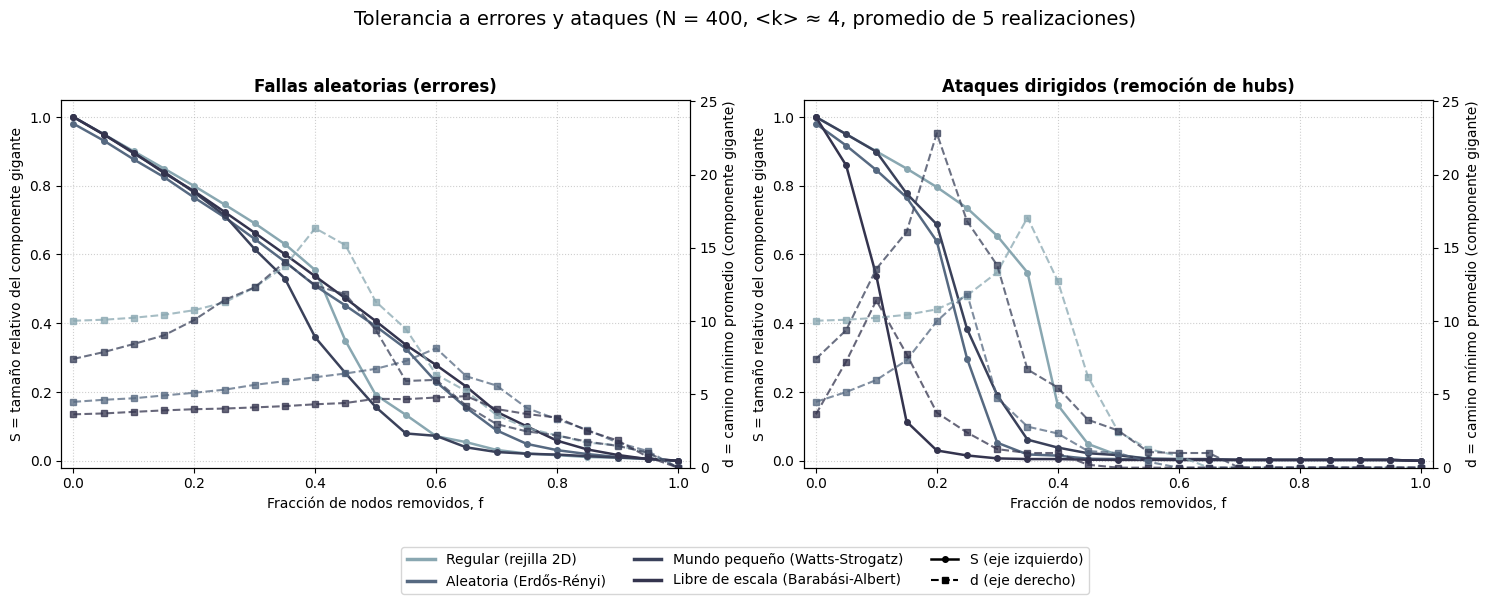

In [35]:
def graficar_resultados(fracciones, res_falla, res_ataque):
    fig, (ax_izq, ax_der) = plt.subplots(1, 2, figsize=(15, 6))

    d_max = max(
        max(np.max(d) for _, d in res_falla.values()),
        max(np.max(d) for _, d in res_ataque.values()),
    )

    dibujar_panel(ax_izq, fracciones, res_falla,
                  "Fallas aleatorias (errores)", d_max)
    dibujar_panel(ax_der, fracciones, res_ataque,
                  "Ataques dirigidos (remoción de hubs)", d_max)

    elementos = [Line2D([0], [0], color=COLORES[n], lw=2.5, label=n)
                 for n in CONSTRUCTORES]
    elementos += [
        Line2D([0], [0], color="black", lw=1.8, marker="o", ms=4,
               label="S (eje izquierdo)"),
        Line2D([0], [0], color="black", lw=1.5, ls="--", marker="s", ms=4,
               label="d (eje derecho)"),
    ]
    fig.legend(handles=elementos, loc="lower center", ncol=3, fontsize=10, frameon=True)

    fig.suptitle(
        f"Tolerancia a errores y ataques (N = {N_NODOS}, <k> ≈ {K_MEDIO}, "
        f"promedio de {N_REALIZACIONES} realizaciones)",
        fontsize=14)

    fig.tight_layout(rect=[0, 0.12, 1, 0.95])
    plt.show()
    return fig

fig = graficar_resultados(fracciones, res_falla, res_ataque)